# Principal Component Analysis with Cancer Data

In [64]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
from scipy.stats import zscore
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [6]:
can_df = pd.read_csv("breast-cancer-wisconsin-data.csv")
can_df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [0]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [14]:
for col in can_df:
    if pd.api.types.is_numeric_dtype(can_df[col]):
        print (can_df[col].dtype)


int64
int64
int64
int64
int64
int64
int64
int64
int64
int64


In [37]:
can_df.shape

(699, 11)

In [38]:
can_df.dtypes

ID                              int64
ClumpThickness                  int64
Cell Size                       int64
Cell Shape                      int64
Marginal Adhesion               int64
Single Epithelial Cell Size     int64
Bare Nuclei                    object
Normal Nucleoli                 int64
Bland Chromatin                 int64
Mitoses                         int64
Class                           int64
dtype: object

In [29]:
can_df.mean()

ID                             1.071704e+06
ClumpThickness                 4.417740e+00
Cell Size                      3.134478e+00
Cell Shape                     3.207439e+00
Marginal Adhesion              2.806867e+00
Single Epithelial Cell Size    3.216023e+00
Normal Nucleoli                3.437768e+00
Bland Chromatin                2.866953e+00
Mitoses                        1.589413e+00
Class                          2.689557e+00
dtype: float64

In [30]:
can_df.var()

ID                             3.808071e+11
ClumpThickness                 7.928395e+00
Cell Size                      9.311403e+00
Cell Shape                     8.832265e+00
Marginal Adhesion              8.153191e+00
Single Epithelial Cell Size    4.903124e+00
Normal Nucleoli                5.945620e+00
Bland Chromatin                9.324680e+00
Mitoses                        2.941492e+00
Class                          9.049194e-01
dtype: float64

In [34]:
can_df.describe()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [25]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

duplicaterowsdf = can_df[can_df.duplicated()]
duplicaterowsdf

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
208,1218860,1,1,1,1,1,1,3,1,1,2
253,1100524,6,10,10,2,8,10,7,3,3,4
254,1116116,9,10,10,1,10,8,3,3,1,4
258,1198641,3,1,1,1,2,1,3,1,1,2
272,320675,3,3,5,2,3,10,7,1,1,4
338,704097,1,1,1,1,1,1,2,1,1,2
561,1321942,5,1,1,1,2,1,3,1,1,2
684,466906,1,1,1,1,2,1,1,1,1,2


In [31]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?
can_df = can_df.replace('?', np.nan)



In [32]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

can_df = can_df.apply(lambda x: x.fillna(x.median()),axis=0)

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [51]:
# Check for correlation of variable

rs = np.random.RandomState(0)
df = pd.DataFrame(rs.rand(10, 10))
corr = can_df.corr()
corr.style.background_gradient(cmap='coolwarm')




,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ID,1,-0.0553084,-0.0416033,-0.0415761,-0.0648781,-0.0455283,-0.0600505,-0.052072,-0.0349007,-0.0802256
ClumpThickness,-0.0553084,1,0.644913,0.654589,0.486356,0.521816,0.558428,0.535835,0.350034,0.716001
Cell Size,-0.0416033,0.644913,1,0.906882,0.705582,0.751799,0.755721,0.722865,0.458693,0.817904
Cell Shape,-0.0415761,0.654589,0.906882,1,0.683079,0.719668,0.735948,0.719446,0.438911,0.818934
Marginal Adhesion,-0.0648781,0.486356,0.705582,0.683079,1,0.599599,0.666715,0.603352,0.417633,0.6968
Single Epithelial Cell Size,-0.0455283,0.521816,0.751799,0.719668,0.599599,1,0.616102,0.628881,0.479101,0.682785
Normal Nucleoli,-0.0600505,0.558428,0.755721,0.735948,0.666715,0.616102,1,0.665878,0.344169,0.756616
Bland Chromatin,-0.052072,0.535835,0.722865,0.719446,0.603352,0.628881,0.665878,1,0.428336,0.712244
Mitoses,-0.0349007,0.350034,0.458693,0.438911,0.417633,0.479101,0.344169,0.428336,1,0.42317
Class,-0.0802256,0.716001,0.817904,0.818934,0.6968,0.682785,0.756616,0.712244,0.42317,1


TypeError: 1.0 is not a string

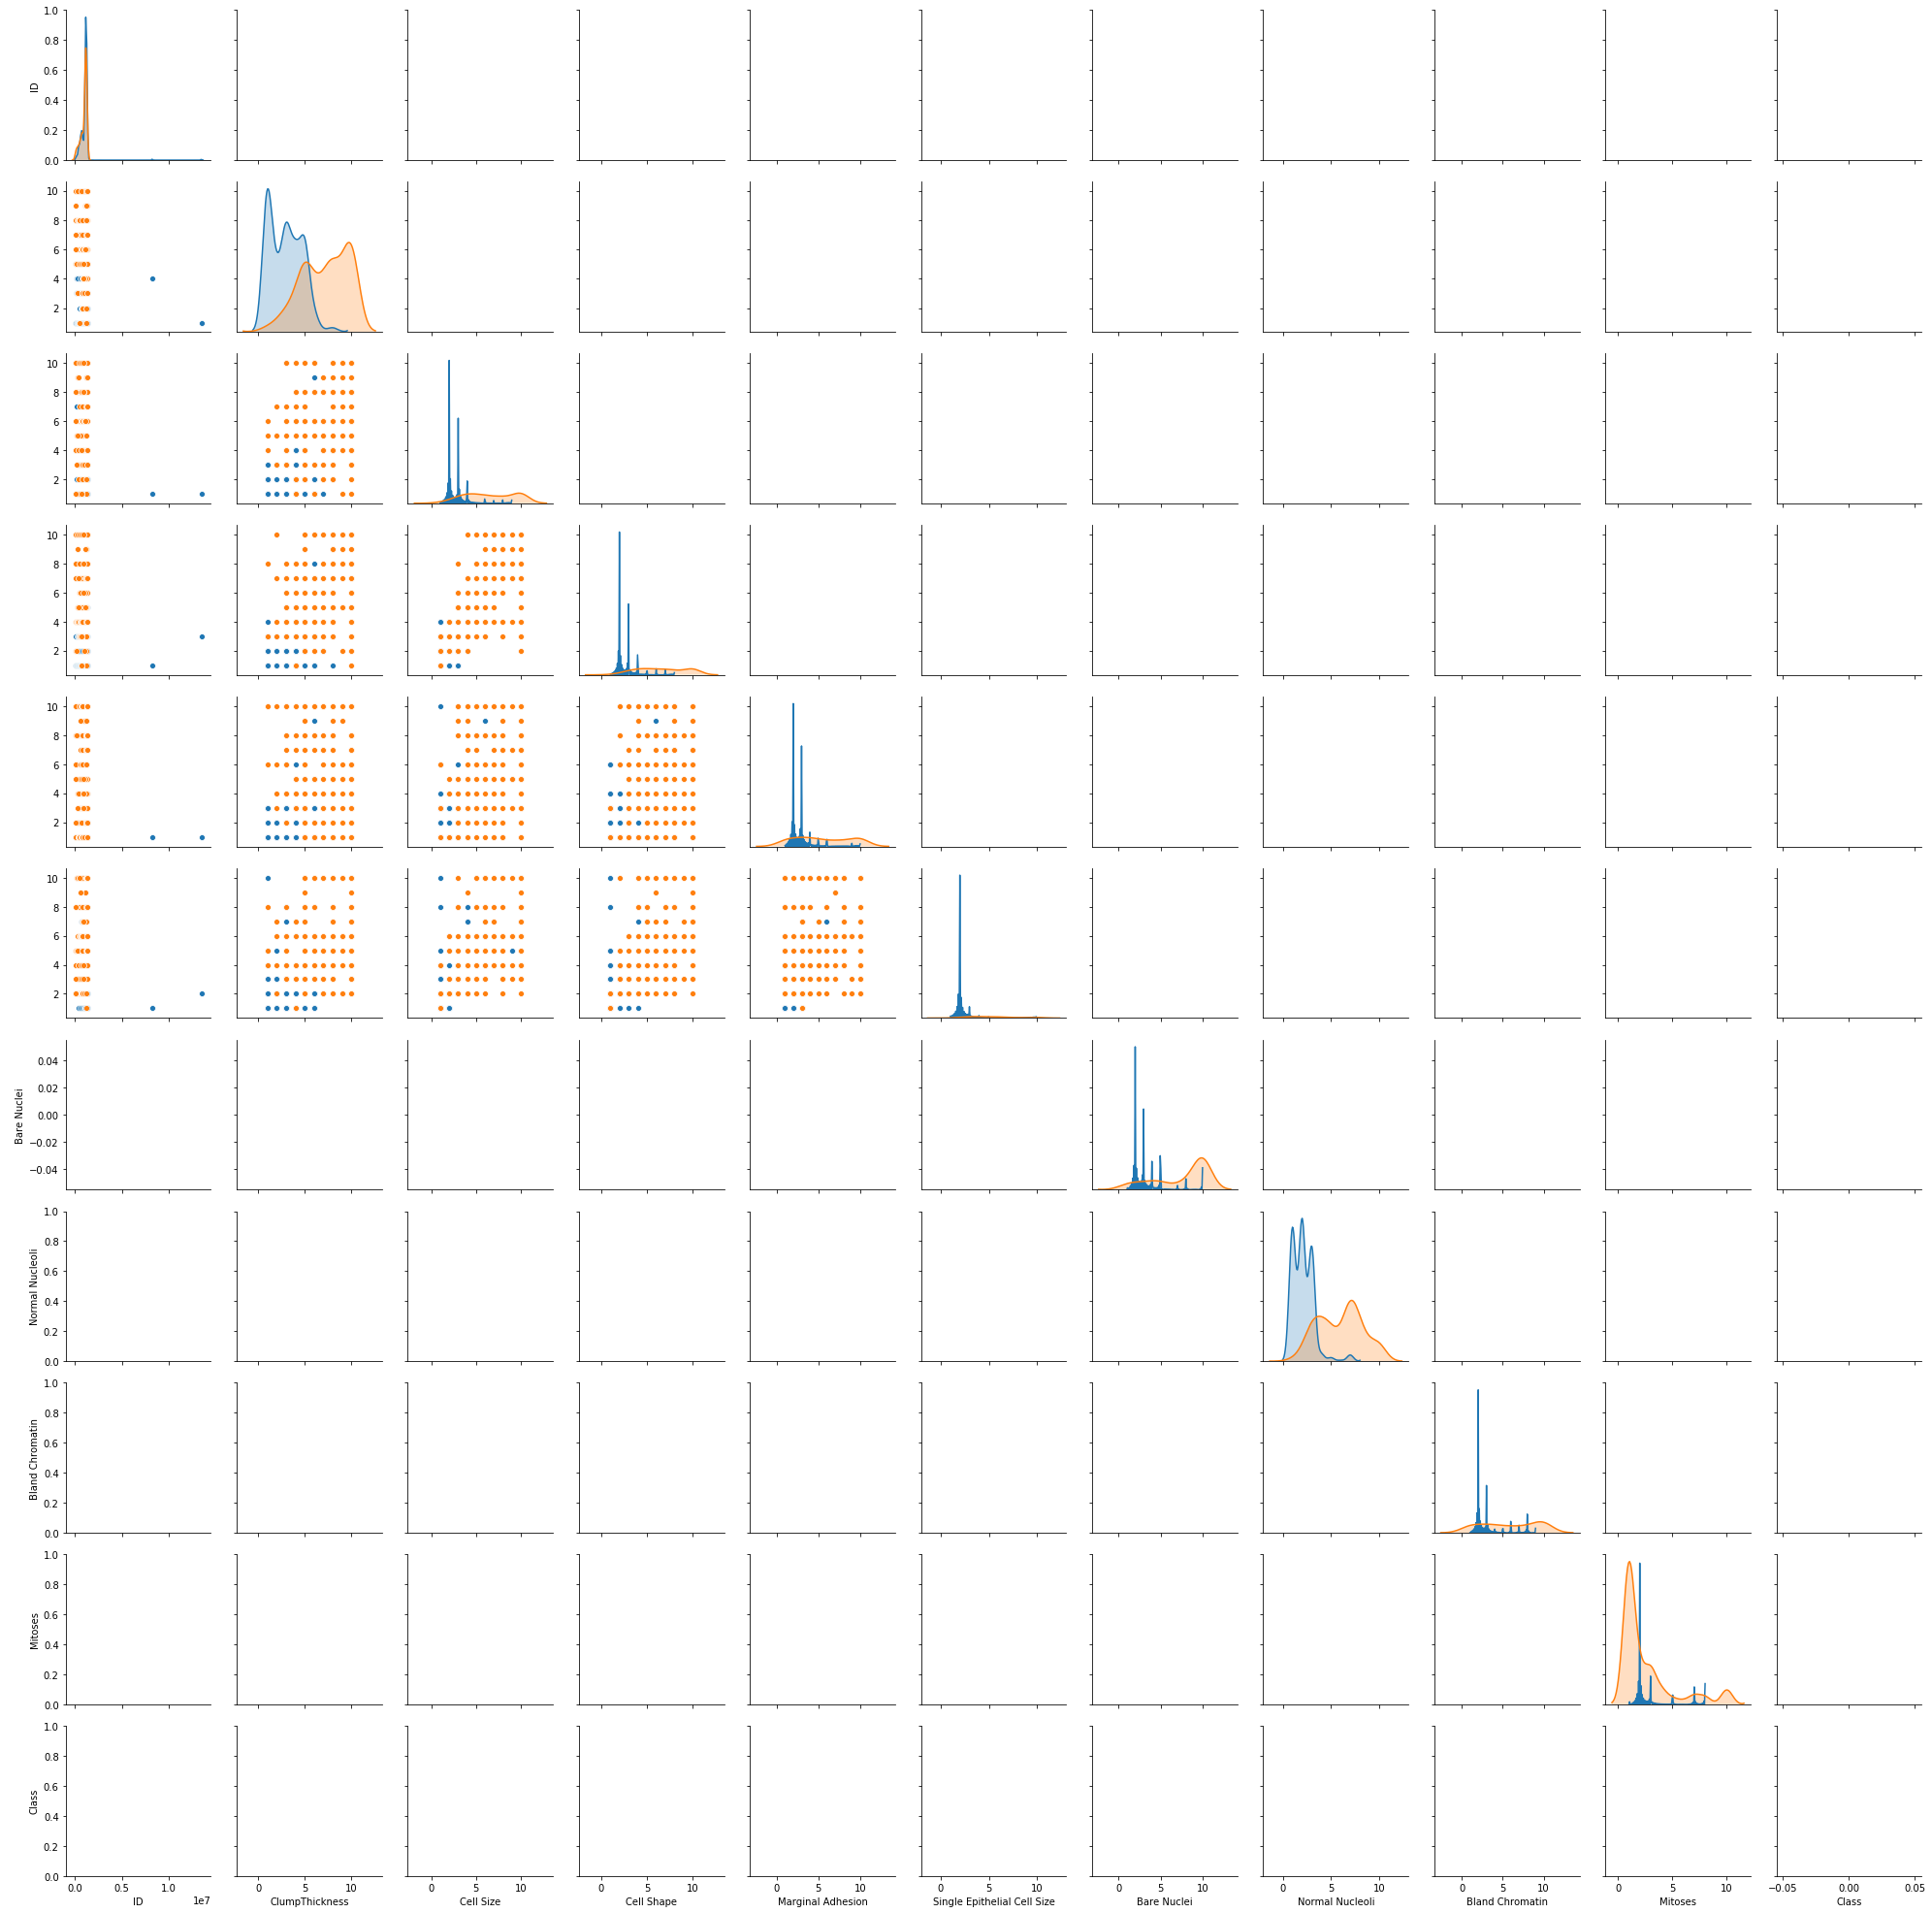

In [52]:
#Let us check for pair plots

sns.pairplot(can_df, hue = 'Class')

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [0]:
# We could see most of the outliers are now removed.

In [56]:
can_df = StandardScaler().fit_transform(can_df)

pd.DataFrame(can_df).describe().transpose()

C:\Users\Rahul\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, object were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\Rahul\Anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, object were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


,count,mean,std,min,25%,50%,75%,max
0,699.0,-1.446943e-16,1.000716,-1.637985,-0.325978,0.162175,0.270158,20.080377
1,699.0,1.655011e-16,1.000716,-1.214667,-0.859266,-0.148465,0.562336,1.983939
2,699.0,-2.801765e-16,1.000716,-0.699995,-0.699995,-0.699995,0.611792,2.251526
3,699.0,-5.854481e-16,1.000716,-0.743299,-0.743299,-0.743299,0.603599,2.287222
4,699.0,-1.477121e-16,1.000716,-0.633247,-0.633247,-0.633247,0.418154,2.520955
5,699.0,-1.021199e-15,1.000716,-1.001495,-0.549561,-0.549561,0.354305,3.065906
6,699.0,7.026648e-16,1.000716,-0.686979,-0.686979,-0.686979,0.418196,1.799664
7,699.0,6.251556e-16,1.000716,-1.000471,-0.590067,-0.179662,0.641147,2.693171
8,699.0,3.874662e-16,1.000716,-0.611825,-0.611825,-0.611825,0.371315,2.337594
9,699.0,7.093356e-16,1.000716,-0.343912,-0.343912,-0.343912,-0.343912,4.907421


# Q6 Create a covariance matrix for identifying Principal components

In [0]:
# PCA
# Step 1 - Create covariance matrix


In [67]:
X = can_df[can_df.columns[1:-1]]
y = can_df["Clump Thickness"]
sc = StandardScaler()
X_std =  sc.fit_transform(X)          
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

# Q7 Identify eigen values and eigen vector

In [0]:
# Step 2- Get eigen values and eigen vector

In [66]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

NameError: name 'cov_matrix' is not defined

# Q8 Find variance and cumulative variance by each eigen vector

In [65]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)] 
cum_var_exp = np.cumsum(var_explained)  


NameError: name 'eigenvalues' is not defined

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [63]:
from sklearn.decomposition import PCA

In [0]:
pca = PCA(n_components=2)
pca.fit(X_centered)


# Q10 Find correlation between components and features